# ***EDA - BTC onchain***

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython import display

In [5]:
data = pd.read_csv("../data/preprocessed/btc_onchain_daily_preprocessed.csv")

# **Normal EDA**

## Descriptive Statistic - ungraphic

### Some info

In [7]:
# shape
print(f'+ Shape: {data.shape}')
# types
print(f'+ Data Types: \n{data.dtypes}')
# head, tail
print(f'+ Contents: ')
display.display(data.head(5))
display.display(data.tail(5))
# info
data.info()

+ Shape: (4143, 10)
+ Data Types: 
date                                  str
price_usd                           int64
active_addresses                    int64
tx_count                            int64
hash_rate                           int64
supply_current                      int64
fee_usd                             int64
difficulty                          int64
miner_revenue_usd                   int64
estimated_transaction_volume_usd    int64
dtype: object
+ Contents: 


,date,price_usd,active_addresses,tx_count,hash_rate,supply_current,fee_usd,difficulty,miner_revenue_usd,estimated_transaction_volume_usd
0,2015-01-01,315,145765,60177,333345,13675615,2989,40640955017,1519572,25914596
1,2015-01-02,316,212932,83050,333345,13679740,4047,40640955017,1475784,41275152
2,2015-01-03,286,241755,81404,327284,13683790,4357,40640955017,1586907,90356063
3,2015-01-04,263,235011,82769,347487,13688090,7190,40640955017,1632203,82599915
4,2015-01-05,275,242515,95721,315163,13691990,4616,40640955017,1202039,68422951


,date,price_usd,active_addresses,tx_count,hash_rate,supply_current,fee_usd,difficulty,miner_revenue_usd,estimated_transaction_volume_usd
4138,2026-05-01,78133,751425,597457,1064992342,20023245,216951,135594876535256,36372876,7051613813
4139,2026-05-02,78713,620486,529423,896831741,20023670,220106,132770520277053,36532352,2098986460
4140,2026-05-03,78649,583469,596099,1000953351,20024145,223262,132472011079032,36691827,1787557345
4141,2026-05-04,79826,722079,567474,981197687,20024611,226418,132472011079032,36851303,7880460115
4142,2026-05-05,80937,721256,589261,987782912,20025079,229573,132472011079032,37010778,8837709858


<class 'pandas.DataFrame'>
RangeIndex: 4143 entries, 0 to 4142
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   date                              4143 non-null   str  
 1   price_usd                         4143 non-null   int64
 2   active_addresses                  4143 non-null   int64
 3   tx_count                          4143 non-null   int64
 4   hash_rate                         4143 non-null   int64
 5   supply_current                    4143 non-null   int64
 6   fee_usd                           4143 non-null   int64
 7   difficulty                        4143 non-null   int64
 8   miner_revenue_usd                 4143 non-null   int64
 9   estimated_transaction_volume_usd  4143 non-null   int64
dtypes: int64(9), str(1)
memory usage: 323.8 KB


**Comment**:
- Data has 9 cols with dtype=int64 (i have converted) and 1 col is data-time
- On different scales and diff range
- Total rows: 4143

### Data integrity (tính toàn vẹn)

In [10]:
print("-"*11, "Check null", "-"*11)
display.display(data.isnull().sum())
has_null = data.isnull().sum().any()
print(f'--> Có giá trị Null: {has_null}')

if has_null:
    display.display(data[data.isnull().any(axis=1)])

----------- Check null -----------


date                                0
price_usd                           0
active_addresses                    0
tx_count                            0
hash_rate                           0
supply_current                      0
fee_usd                             0
difficulty                          0
miner_revenue_usd                   0
estimated_transaction_volume_usd    0
dtype: int64

--> Có giá trị Null: False


In [13]:
print("="*5, "Checking NaN", "="*5)
display.display(data.isna().sum())
has_nan  = data.isna().sum().any()
print(f'--> Có giá trị Nan: {has_nan}')
if has_nan:
    display.display(data[data.isna().any(axis=1)])

===== Checking NaN =====


date                                0
price_usd                           0
active_addresses                    0
tx_count                            0
hash_rate                           0
supply_current                      0
fee_usd                             0
difficulty                          0
miner_revenue_usd                   0
estimated_transaction_volume_usd    0
dtype: int64

--> Có giá trị Nan: False


### Mối tương quan giữa các tính chất (Correlations)

Sự tương quan (correlation) đề cập đến mối quan hệ giữa hai biến và cách chúng có thể có hoặc không cùng nhau thay đổi.

Phương pháp phổ biến nhất để tính toán tương quan là Pearson's Correlation Coeficient, giả định có một phân phối chuẩn của các thuộc tính liên quan. Tương quan -1 hoặc 1 cho thấy mối tương quan âm hoặc dương đầy đủ tương ứng. Trong khi giá trị 0 hiển thị không tương quan ở tất cả.

$$
r = \frac{\sum_{i=1}^n{\left(x_i - \hat{x}\right)\left(y_i - \hat{y}\right)}}{\sqrt{\sum_{i=1}^n{\left(x_i - \hat{x}\right)^2}\sum_{i=1}^n{\left(y_i - \hat{y}\right)^2}}}
$$

Một số thuật toán học máy như hồi quy tuyến tính và logistic có hiệu suất kém nếu có các thuộc tính tương quan cao trong tập dữ liệu.

Như vậy, thật sự cần thiết để xem xét tất cả các mối tương quan theo cặp của các thuộc tính trong tập dữ liệu.

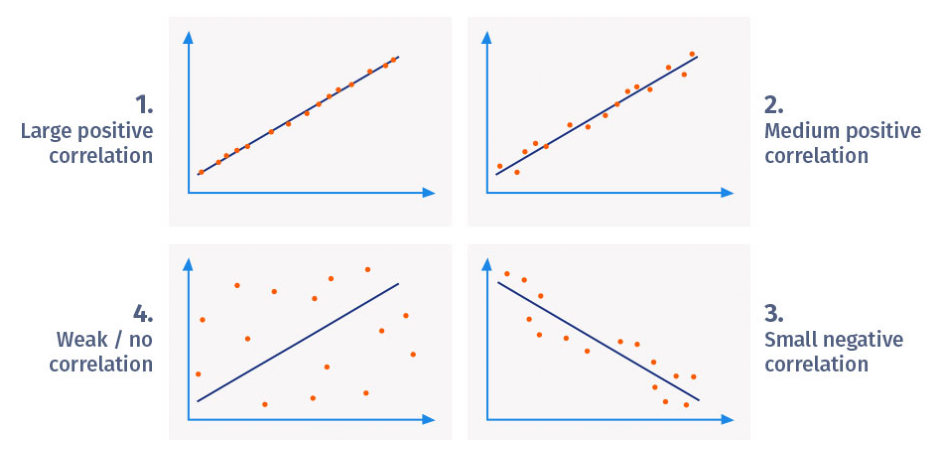

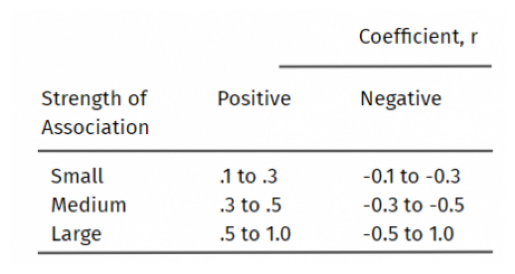

In [22]:
plt.figure(figsize=(12, 6))
plt.imshow(plt.imread("corr1.png")), plt.axis("off"), plt.show();
plt.imshow(plt.imread("corr2.png")), plt.axis("off"), plt.show();

In [21]:
correlations = data.drop(columns=['date']).corr(method='pearson')
display.display(correlations)

,price_usd,active_addresses,tx_count,hash_rate,supply_current,fee_usd,difficulty,miner_revenue_usd,estimated_transaction_volume_usd
price_usd,1.000000,0.276998,0.596398,0.912063,0.741814,0.145014,0.915980,0.846548,0.797436
active_addresses,0.276998,1.000000,0.377018,0.171466,0.665087,0.332049,0.163746,0.558454,0.357726
tx_count,0.596398,0.377018,1.000000,0.701487,0.692805,0.272838,0.680884,0.541829,0.492547
hash_rate,0.912063,0.171466,0.701487,1.000000,0.735464,0.070386,0.992571,0.694494,0.720331
supply_current,0.741814,0.665087,0.692805,0.735464,1.000000,0.181542,0.737433,0.764335,0.608678
fee_usd,0.145014,0.332049,0.272838,0.070386,0.181542,1.000000,0.069662,0.415746,0.191536
difficulty,0.915980,0.163746,0.680884,0.992571,0.737433,0.069662,1.000000,0.679918,0.726703
miner_revenue_usd,0.846548,0.558454,0.541829,0.694494,0.764335,0.415746,0.679918,1.000000,0.716584
estimated_transaction_volume_usd,0.797436,0.357726,0.492547,0.720331,0.608678,0.191536,0.726703,0.716584,1.000000


**Comment**:
- Ohh right! *High correlation* between all numeric columns
    + Corr with `price_usd` almost cols is high corr, except: active_addresses and fee_usd. The most corr: `hash_rate` & `difficulty` (~0.91) with `price_usdt`

## Descriptive Statistic - graphic

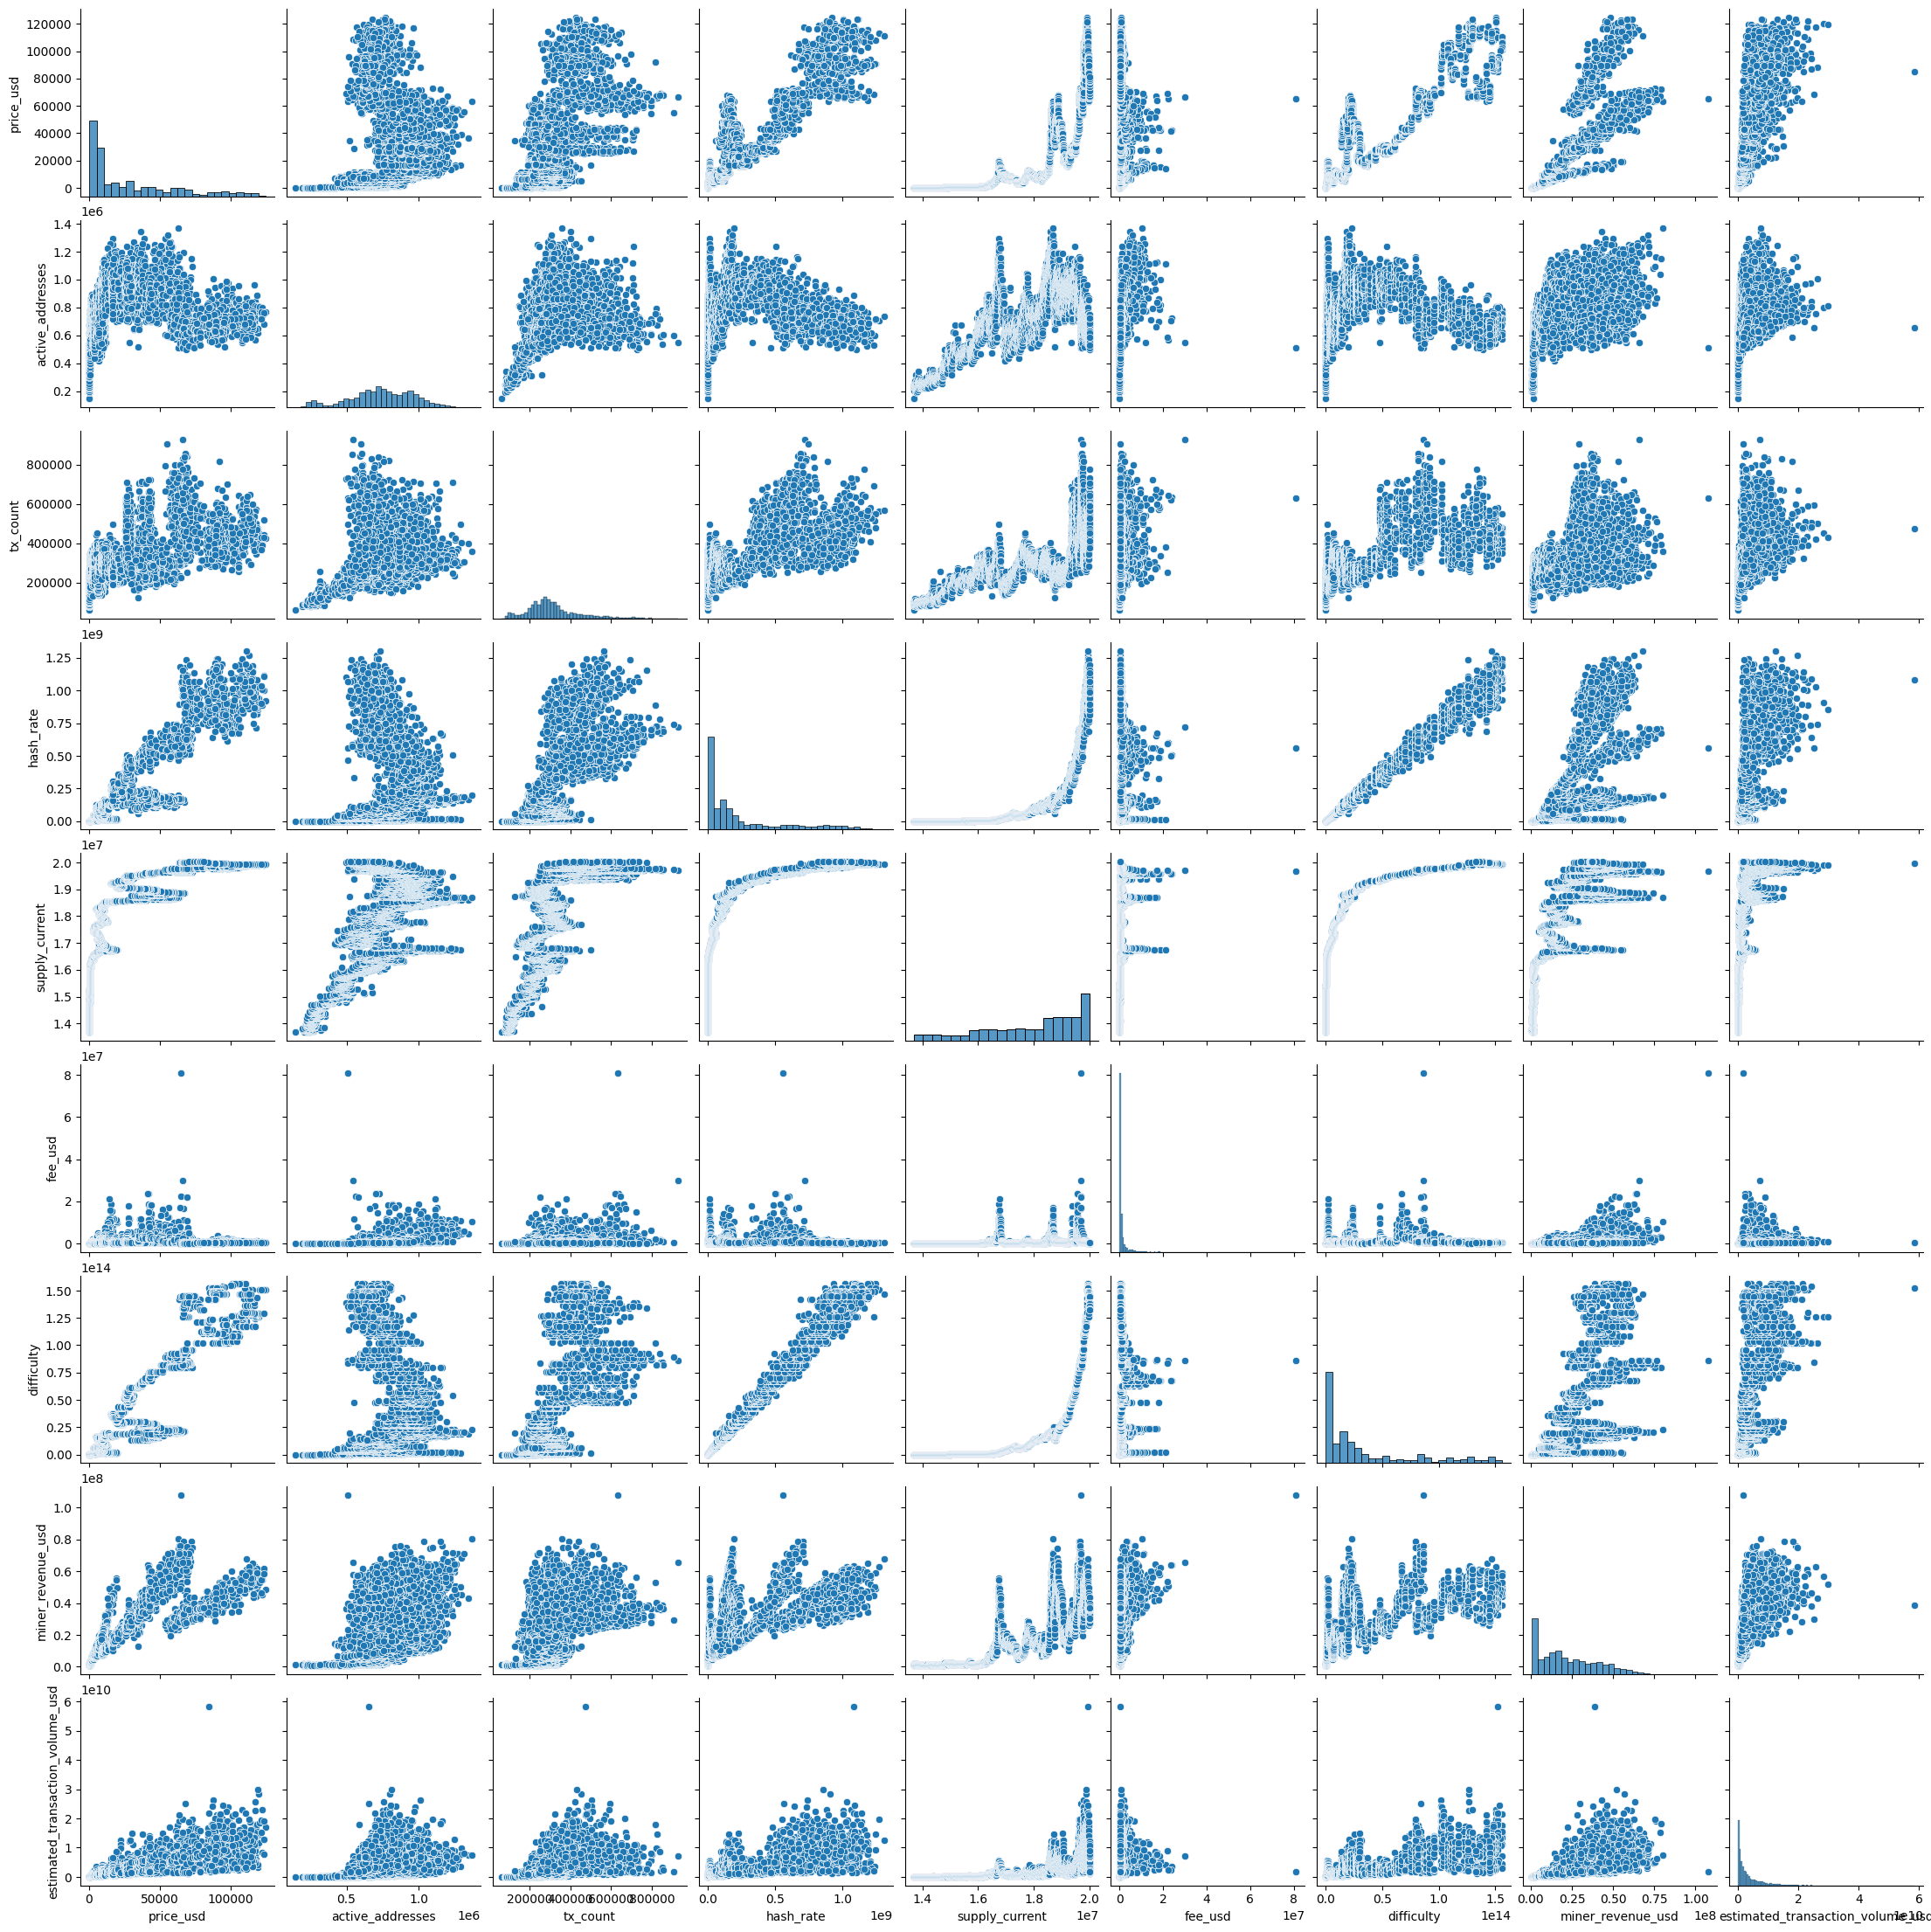

In [31]:
sns.pairplot(data)

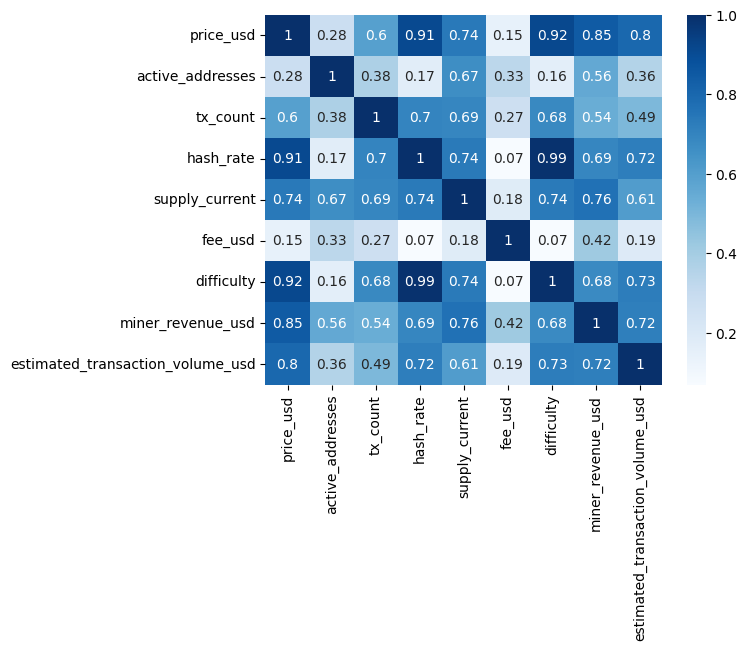

In [36]:
# fig = plt.figure(figsize = (24,12))
sns.heatmap(data.drop(columns=['date']).corr(), cmap='Blues', annot = True);

# **Time series EDA**

- Plot time series
- Distribution analysis
- Correlation analysis
- Rolling statistics
- Seasonality decomposition
- Stationarity test
- Lag relationship
- Outlier detection
- Feature engineering ideas
- Kết luận cho modeling